In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import torch

import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
%pip install stopwords
%pip install gensim
from stopwords import get_stopwords
from sklearn.model_selection import train_test_split

from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModel, GPT2Tokenizer, AutoModelForSequenceClassification

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec
from gensim.models.fasttext import FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import nltk

import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import numpy as np
import random
import torch
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np
from torch.utils.data import TensorDataset, DataLoader


import torch
import pandas as pd
%pip install datasets
from datasets import load_dataset, Dataset
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
import pyreadr

df = list(pyreadr.read_r('/content/drive/MyDrive/hdmo.rds').values())[0]
df.head()


ModuleNotFoundError: No module named 'pyreadr'

# utils

In [ ]:
def plot_attention(text, model_name = "bert-base-uncased"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_attentions=True)  #get attention weights

    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    # extract attention weights
    # outputs.attentions is a tuple, each element corresponds to the attention weights of one layer
    # for simplicity, let's get attention weights from the last layer
    attention_weights = outputs.attentions[-1]  # Shape: (batch_size, num_heads, seq_len, seq_len)

    # convert attention weights to numpy for easier handling
    attention_weights = attention_weights.squeeze(0).detach().numpy()  #remove batch dimension

    # choose a specific attention head for visualization (e.g., head 0)
    attention_weights_head_0 = attention_weights[0]  #shape: (seq_len, seq_len)

    # get the list of tokens (words/subwords)
    tokens = tokenizer.tokenize(text)
    #tokens = ["[CLS]"] + tokens + ["[SEP]"]  # Add CLS and SEP tokens

    #plt.figure(figsize=(8, 6))
    #sns.heatmap(attention_weights_head_0, annot=True, xticklabels=tokens, yticklabels=tokens, cmap="YlGnBu", cbar=True)
    #
    #plt.title("Attention Weights Heatmap from BERT")
    #plt.xlabel("Tokens (Keys)")
    #plt.ylabel("Tokens (Queries)")
    #plt.show()

    tokens = [token for token in tokens if token not in ["[CLS]", "[SEP]"]]  # Remove [CLS] and [SEP]

    # 8. Adjust the attention weights to match the tokens after removing [CLS] and [SEP]
    # The attention weight matrix must also exclude the corresponding rows/columns for [CLS] and [SEP]
    attention_weights_head_0 = attention_weights_head_0[1:-1, 1:-1]  # Remove [CLS] and [SEP] attention rows/columns

    plt.figure(figsize=(10,10))
    sns.heatmap(attention_weights_head_0, annot=True, xticklabels=tokens, yticklabels=tokens, cmap="YlGnBu", cbar=False,
                linewidths=0.5, linecolor='black', square=False)

    plt.yticks(rotation=0)
    plt.title("Attention Weights Heatmap from BERT")
    plt.xlabel("Tokens (Keys)")
    plt.ylabel("Tokens (Queries)")
    #plt.savefig('attention.png', dpi=600, bbox_inches='tight')
    plt.show()

def plot_vectorization(outputs,tokenizer):
    # A legutolsó rejtett réteg kimenete
    last_hidden_states = outputs.last_hidden_state

    # Az első 3 dimenzió kiválasztása a vektorokból
    vector_data = last_hidden_states[0][:, :3].numpy()

    # A tokenek nevei
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Ábra készítése
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection='3d')

    # A vektorok kirajzolása 3D-ben
    ax.scatter(vector_data[:, 0], vector_data[:, 1], vector_data[:, 2], c='b', marker='o')

    # Címkék hozzáadása
    for i, token in enumerate(tokens):
        ax.text(vector_data[i, 0], vector_data[i, 1], vector_data[i, 2], token, size=10)

    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_zlabel('Dimension 3')
    ax.set_title('BERT Embedding vector\'s first 3 dimension from 768')

    plt.show()

# Tokenizers

In [ ]:
text = "I'm learning tokenization :)"

In [ ]:
tokens = re.findall(r'\b\w+\b', text)
print("Szabályalapú (szavakra) tokenizálás:", tokens)

tokens = word_tokenize(text)
print("Szabályalapú (szavak+írásjelek) tokenizálás:", tokens)

tokens = AutoTokenizer.from_pretrained('bert-base-uncased').tokenize(text)
print("BERT - WordPiece tokenizálás:", tokens)

tokens = AutoTokenizer.from_pretrained('roberta-base').tokenize(text)
print("RoBERTa - BPE-alapú tokenizálás:", tokens)

tokens = GPT2Tokenizer.from_pretrained("gpt2").tokenize(text)
print("GPT2 - BPE-alapú tokenizálás:", tokens)


Szabályalapú (szavakra) tokenizálás: ['I', 'm', 'learning', 'tokenization']
Szabályalapú (szavak+írásjelek) tokenizálás: ['I', "'m", 'learning', 'tokenization', ':', ')']


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

GPT2 - BPE-alapú tokenizálás: ['I', "'m", 'Ġlearning', 'Ġtoken', 'ization', 'Ġ:)']


In [ ]:
#transformer: weight tokens with attention
plot_attention(
    text = text,
    model_name = 'roberta-base'
)

NameError: name 'plot_attention' is not defined

# Vectorization techniques

In [ ]:
# Sample text
texts = [
    "I love programming",
    "Python is awesome",
    "I hate bugs",
    "I despise dirty data",
    "I hate missing values",
    "I struggle with high-dimensional data",
    "Debugging is fun",
    "I love solving problems",
    "Python programming is great",
    "I dislike errors",
    "Programming is challenging but rewarding",
    "I enjoy coding",
    "Bugs are annoying",
]

tokenized_texts = [nltk.word_tokenize(text.lower()) for text in texts]

tokenized_texts

[['i', 'love', 'programming'],
 ['python', 'is', 'awesome'],
 ['i', 'hate', 'bugs'],
 ['i', 'despise', 'dirty', 'data'],
 ['i', 'hate', 'missing', 'values'],
 ['i', 'struggle', 'with', 'high-dimensional', 'data'],
 ['debugging', 'is', 'fun'],
 ['i', 'love', 'solving', 'problems'],
 ['python', 'programming', 'is', 'great'],
 ['i', 'dislike', 'errors'],
 ['programming', 'is', 'challenging', 'but', 'rewarding'],
 ['i', 'enjoy', 'coding'],
 ['bugs', 'are', 'annoying']]

In [ ]:
# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the tokenized data
X_bow = vectorizer.fit_transform([' '.join(tokens) for tokens in tokenized_texts])

# Convert to dense array and display
print("Bag of Words (BoW) Representation:")
print(X_bow.toarray())
print("Vocabulary:", vectorizer.get_feature_names_out())


Bag of Words (BoW) Representation:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Vocabulary: ['annoying' 'are' 'awesome' 'bugs' 'but' 'challenging' 'coding' 'data'
 'debugging' 'despise' 'dimensional' 'dirty' 'dislike' 'enjoy'

In [ ]:
# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the tokenized data
X_tfidf = vectorizer.fit_transform([' '.join(tokens) for tokens in tokenized_texts])

# Convert to dense array and display
print("TF-IDF Representation:")
print(X_tfidf.toarray())
print("Vocabulary:", vectorizer.get_feature_names_out())


TF-IDF Representation:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.74820002 0.         0.         0.66347324
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.67140729 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.46257394 0.         0.         0.         0.
  0.57899706 0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.70710678 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.70710678
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.        

In [ ]:
model = Word2Vec(tokenized_texts, vector_size=10, window=3, min_count=1, workers=4)

# Print the word vectors for 'python' and 'programming'
print("Word2Vec Vector for 'python':", model.wv['python'])
print("Word2Vec Vector for 'programming':", model.wv['programming'])

Word2Vec Vector for 'python': [-0.01577249  0.00321153 -0.04140168 -0.07682756 -0.01508744  0.02470498
 -0.00887691  0.05534135 -0.02743204  0.02260412]
Word2Vec Vector for 'programming': [ 0.07311766  0.05070262  0.06757693  0.00762866  0.06350891 -0.03405366
 -0.00946401  0.05768573 -0.07521638 -0.03936104]


In [ ]:
model = FastText(sentences=tokenized_texts, vector_size=10, window=3, min_count=1, workers=4)

# Print the word vectors for 'python' and 'programming'
print("FastText Vector for 'python':", model.wv['python'])
print("FastText Vector for 'programming':", model.wv['programming'])


FastText Vector for 'python': [ 0.00410517 -0.02251537  0.00228123 -0.02320736 -0.02226789  0.00529886
  0.00834255  0.00795109 -0.01596039 -0.00683755]
FastText Vector for 'programming': [ 4.1161645e-03  1.2433991e-02 -8.9462930e-03  6.1576939e-03
  6.7247404e-03 -6.8565772e-04  9.4334837e-03  6.0122861e-03
 -1.3243925e-03  2.6477179e-05]


In [ ]:
from transformers import AutoTokenizer, BertModel
import torch

# Töltsük le a BERT tokenizálót és modellt
tokenizer = AutoTokenizer.from_pretrained('roberta-base')  # BERT alap modell, angol nyelvhez
model = AutoModel.from_pretrained('roberta-base')

# Tokenizálás: a szöveget tokenekre bontjuk
inputs = tokenizer(text, return_tensors='pt', add_special_tokens=True)

# Tokenek kódolása és vektorizálása
with torch.no_grad():
    outputs = model(**inputs)

print("Shape of last hidden states:", outputs.last_hidden_state.shape)

# A tokenek és azok vektorai
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
for token, vector in zip(tokens, outputs.last_hidden_state[0]):
    print(f"Token: {token}, Vector: {vector[:5]}...")  # Csak az első 5 értéket mutatjuk


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Shape of last hidden states: torch.Size([1, 8, 768])
Token: <s>, Vector: tensor([-0.0425,  0.0724, -0.0411, -0.1198,  0.0861])...
Token: I, Vector: tensor([ 0.0749,  0.1261, -0.1398, -0.1357,  0.3515])...
Token: 'm, Vector: tensor([ 0.0582,  0.0864,  0.0494, -0.1390,  0.3594])...
Token: Ġlearning, Vector: tensor([ 0.0877, -0.1540,  0.0493,  0.2232,  1.0066])...
Token: Ġtoken, Vector: tensor([ 0.2042, -0.2163, -0.1051, -0.0710,  0.1598])...
Token: ization, Vector: tensor([0.0051, 0.0435, 0.0435, 0.0121, 0.1250])...
Token: Ġ:), Vector: tensor([ 0.1548, -0.2423, -0.0041, -0.1150,  0.4405])...
Token: </s>, Vector: tensor([-0.0342,  0.0688, -0.0764, -0.1068,  0.1044])...


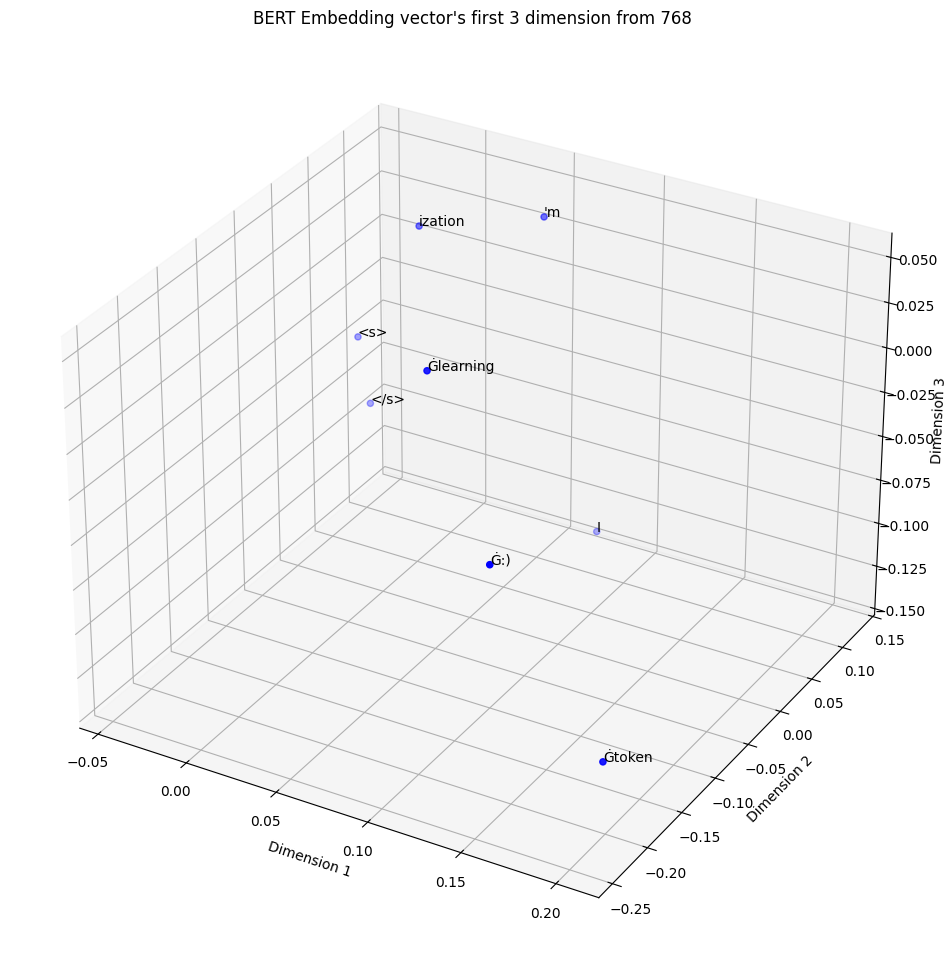

In [ ]:
plot_vectorization(outputs, tokenizer)

# Data preparation

In [ ]:
dummy_df = pd.DataFrame({
    "text": [
        "I love programming",
        "Python is awesome",
        "I hate bugs",
        "I despise dirty data",
        "I hate missing values",
        "I struggle with high-dimensional data",
        "Debugging is fun",
        "I love solving problems",
        "Python programming is great",
        "I dislike errors",
        "Programming is challenging but rewarding",
        "I enjoy coding",
        "Bugs are annoying",
    ],
    'label': [1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0]
})

#tokenize (word tokenization)
dummy_df['token'] = dummy_df['text'].apply(word_tokenize)

#vectorisation
model = FastText(sentences=dummy_df['token'].to_list(), vector_size=2, window=3, min_count=1, workers=4)
dummy_df['vector'] = [[model.wv[word] for word in sentence] for sentence in dummy_df['token'].to_list()]

#word level vectors -> sentence level vectors
def mean_pooling(sequences):
    return np.array([np.mean(seq, axis=0) for seq in sequences])

dummy_X_train = mean_pooling(np.array(dummy_df['vector']))
dummy_y_train = dummy_df['label']

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(dummy_X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(dummy_y_train.values, dtype=torch.long)

# Create DataLoader for batch processing
train_data = TensorDataset(X_train_tensor, y_train_tensor)
dummy_train_loader = DataLoader(train_data, batch_size=4, shuffle=True)

In [ ]:
dummy_df

,text,label,token,vector
0,I love programming,1,"[I, love, programming]","[[-0.20935354, 0.19672686], [-0.03116799, -0.0..."
1,Python is awesome,1,"[Python, is, awesome]","[[0.0016885557, 0.05183307], [0.12686749, 0.20..."
2,I hate bugs,0,"[I, hate, bugs]","[[-0.20935354, 0.19672686], [0.068819255, 0.01..."
3,I despise dirty data,0,"[I, despise, dirty, data]","[[-0.20935354, 0.19672686], [0.089150615, 0.02..."
4,I hate missing values,0,"[I, hate, missing, values]","[[-0.20935354, 0.19672686], [0.068819255, 0.01..."
5,I struggle with high-dimensional data,0,"[I, struggle, with, high-dimensional, data]","[[-0.20935354, 0.19672686], [-0.06703039, 0.04..."
6,Debugging is fun,1,"[Debugging, is, fun]","[[0.037767127, 0.02134928], [0.12686749, 0.200..."
7,I love solving problems,1,"[I, love, solving, problems]","[[-0.20935354, 0.19672686], [-0.03116799, -0.0..."
8,Python programming is great,1,"[Python, programming, is, great]","[[0.0016885557, 0.05183307], [0.021472687, -0...."
9,I dislike errors,0,"[I, dislike, errors]","[[-0.20935354, 0.19672686], [-0.01793368, -0.1..."


In [ ]:
E9_LABELS_DICT = {
    0: 'Anger',
    1: 'Fear',
    2: 'Disgust',
    3: 'Sadness',
    4: 'Joy',
    5: 'None of Them',
    6: 'Enthusiasm',
    7: 'Hope',
    8: 'Pride'
}

E9_2_SENTIMENT_DICT = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 1,
    5: 2,
    6: 1,
    7: 1,
    8: 1
}

SENTIMENT_DICT = {
    0: 'Negative',
    1: 'Positive',
    2: 'Neutral'
}

#read csv
df = pd.read_csv('/content/drive/MyDrive/hu_telex_2020_2024_for_e9_all_sentences_preds.csv')

df

,id,text,pred,pred_name,softmax_0,softmax_1,softmax_2,softmax_3,softmax_4,softmax_5,softmax_6,softmax_7,softmax_8
0,1001c0a40b7e5b08b98f25e71b0c607c_1,Terveket dolgozott ki az orosz kormány arra az...,5,LABEL_5,0.037610,0.163532,0.000812,0.008887,0.003289,0.571820,0.040844,0.167254,0.005953
1,1001c0a40b7e5b08b98f25e71b0c607c_2,"A szóvivő sürgette, hogy az Egyesült Államok h...",5,LABEL_5,0.195384,0.178916,0.001816,0.026978,0.001342,0.224636,0.150208,0.219928,0.000790
2,1001c0a40b7e5b08b98f25e71b0c607c_3,Hangot adott a Kreml aggodalmának a „teljesen ...,1,LABEL_1,0.074608,0.772601,0.001408,0.024052,0.000517,0.115983,0.002668,0.006975,0.001188
3,1001c0a40b7e5b08b98f25e71b0c607c_4,Eközben veszi körül Ukrajnát.,5,LABEL_5,0.027128,0.012623,0.000774,0.006125,0.005085,0.914968,0.010357,0.010552,0.012388
4,1001c0a40b7e5b08b98f25e71b0c607c_5,A belengetett szankciókról .,5,LABEL_5,0.062289,0.004823,0.000649,0.007501,0.003529,0.905891,0.004210,0.008842,0.002266
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1623789,telex_45581_45581,Koronavírussal kapcsolatos hazai hírek egy hel...,5,LABEL_5,0.115883,0.149104,0.012162,0.153206,0.002778,0.551911,0.003697,0.007105,0.004156
1623790,telex_45586_45586,Ha a jogállamisági és költségvetési kérdések ö...,7,LABEL_7,0.013073,0.016357,0.000283,0.003865,0.006039,0.194290,0.106686,0.655472,0.003934
1623791,telex_46142_46142,Dániában 17 millió nyérc elpusztításába kezdte...,0,LABEL_0,0.383514,0.105892,0.083949,0.296988,0.003646,0.116479,0.001989,0.005320,0.002224
1623792,telex_46143_46143,Szájer József brüsszeli orgiája kétségkívül az...,0,LABEL_0,0.816029,0.005735,0.009509,0.013177,0.006355,0.139931,0.002362,0.002516,0.004386


In [ ]:
#rename columns
df = df.rename(columns={'pred':'label', 'pred_name': 'label_name'})

df.label = df.label.astype(int)

df['label_name'] = df['label'].map(E9_LABELS_DICT)

#keep only relevant columns
df = df[['id', 'text', 'label', 'label_name']]

#map E9 labels to Sentiment labels
df['label'] = df['label'].map(E9_2_SENTIMENT_DICT)

#drop None of them category
df = df[df['label_name'] != 'None of Them']

#map sentiment labels
df['label_name'] = df['label'].map(SENTIMENT_DICT)

df

,id,text,label,label_name
2,1001c0a40b7e5b08b98f25e71b0c607c_3,Hangot adott a Kreml aggodalmának a „teljesen ...,0,Negative
5,1001c0a40b7e5b08b98f25e71b0c607c_6,több mint százezer orosz katona ebben a cikkbe...,1,Positive
14,1001c0a40b7e5b08b98f25e71b0c607c_15,A lapban megjelentek szerint az USA és a NATO ...,1,Positive
16,1001c0a40b7e5b08b98f25e71b0c607c_17,"Moszkvának azt a követelését, hogy a NATO infr...",0,Negative
17,1001c0a40b7e5b08b98f25e71b0c607c_18,térjen vissza az 1997-es határokhoz,1,Positive
...,...,...,...,...
1623784,telex_45557_45557,Hégetõ Honorka-díjat kapott a Telex két munkat...,1,Positive
1623790,telex_45586_45586,Ha a jogállamisági és költségvetési kérdések ö...,1,Positive
1623791,telex_46142_46142,Dániában 17 millió nyérc elpusztításába kezdte...,0,Negative
1623792,telex_46143_46143,Szájer József brüsszeli orgiája kétségkívül az...,0,Negative


In [ ]:
#remove stopwords
#stopwords_hu = get_stopwords('hu')
#
#def remove_stopwords(text):
#    return ' '.join([word for word in text.split() if word.lower() not in stopwords_hu])
#
#df['text'] = df['text'].apply(remove_stopwords)

#remove rows with less than 50 characters
min_char_length = 100
max_char_length = 150
df = df[(df['text'].str.len() > min_char_length) & (df['text'].str.len() < max_char_length)]

df.label_name.value_counts()

,count
label_name,
Negative,92894
Positive,67738


In [ ]:
#sample 1000 positive and 1000 negative examples
df = pd.concat(
    [
        df[df['label_name'] == 'Positive'].sample(n=50000, random_state=42),
        df[df['label_name'] == 'Negative'].sample(n=50000, random_state=42)
    ]
)

#shuffle the dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.label_name.value_counts()

,count
label_name,
Negative,50000
Positive,50000


In [ ]:
#tokenize (word tokenization)
df['token'] = df.text.apply(word_tokenize)

#vectorisation
model = FastText(sentences=df['token'].to_list(), vector_size=300, window=3, min_count=1, workers=4)
df['vector'] = [[model.wv[word] for word in sentence] for sentence in df['token'].to_list()]

df

,id,text,label,label_name,token,vector
0,64a49fdb153c1b2480c06e270d1f7ee3_2,A férfit azért támadták meg a hét elején Bihár...,0,Negative,"[A, férfit, azért, támadták, meg, a, hét, elej...","[[-1.5850629, -2.8515532, 1.8598418, 1.1817633..."
1,db219fce119449e99489915d33940a96_7,Viszont ennek lett egy olyan következménye a d...,0,Negative,"[Viszont, ennek, lett, egy, olyan, következmén...","[[0.26532102, -0.02730931, -0.27072683, -0.478..."
2,311f7bef57cd21336187e8682005b1d4_25,"„Ebben Magyarország, a magyar kormány nem lehe...",1,Positive,"[„, Ebben, Magyarország, ,, a, magyar, kormány...","[[-0.44970065, -0.040501904, -0.39017388, 2.08..."
3,3a7f03a49c9e4cc2379fdc058f24ad14_33,"„Nagyon sajnálom, itt minden dolgozó nagyon ke...",0,Negative,"[„, Nagyon, sajnálom, ,, itt, minden, dolgozó,...","[[-0.44970065, -0.040501904, -0.39017388, 2.08..."
4,881b625364e0df21a134311fb2c92ff2_10,Hogy erre a lehengerlő reklámkampányra aztán h...,0,Negative,"[Hogy, erre, a, lehengerlő, reklámkampányra, a...","[[0.5531911, -0.07781977, -0.94977784, -0.3515..."
...,...,...,...,...,...,...
99995,c2ba7ab95e3d944e86fbbb0fa7003362_113,Ilyenkor egy összességében arányosabb választá...,1,Positive,"[Ilyenkor, egy, összességében, arányosabb, vál...","[[0.13157561, -0.06510919, -0.45562625, -0.347..."
99996,749d35b08082f983bdfdbc999611718b_70,"Szomorú, de ha tudod kívülről nézni, a maga ne...",0,Negative,"[Szomorú, ,, de, ha, tudod, kívülről, nézni, ,...","[[0.08267272, -0.037980597, -0.075266175, -0.1..."
99997,60b19259916e8eec1e98501026e60c68_7,Az illetékes belga válságközpont 163 eltűntről...,0,Negative,"[Az, illetékes, belga, válságközpont, 163, elt...","[[2.0403745, 2.6439285, 0.4615362, 1.1055759, ..."
99998,97042ad0762d2b9a8d5befdf2e04b886_1,"Óvodai tornaszobát adott át Vinnai Győző, a Fi...",1,Positive,"[Óvodai, tornaszobát, adott, át, Vinnai, Győző...","[[-0.1858548, -0.07520338, -0.10835458, 0.0409..."


In [ ]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['vector'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

def mean_pooling(sequences):
    return np.array([np.mean(seq, axis=0) for seq in sequences])

X_train_avg = mean_pooling(np.array(X_train))
X_test_avg = mean_pooling(np.array(X_test))

# Models

## Perceptron

In [ ]:
#data preparation
#word level vectors -> sentence level vectors

X_train_tensor = torch.tensor(X_train_avg, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_avg, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create DataLoader for batch processing
train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)

test_data = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_data, batch_size=4, shuffle=False)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Batch 1/10:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 2/10:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 3/10:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 4/10:   0%|          | 0/4 [00:00<?, ?it/s]

...

Batch 6/10:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 7/10:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 8/10:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 9/10:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 10/10:   0%|          | 0/4 [00:00<?, ?it/s]

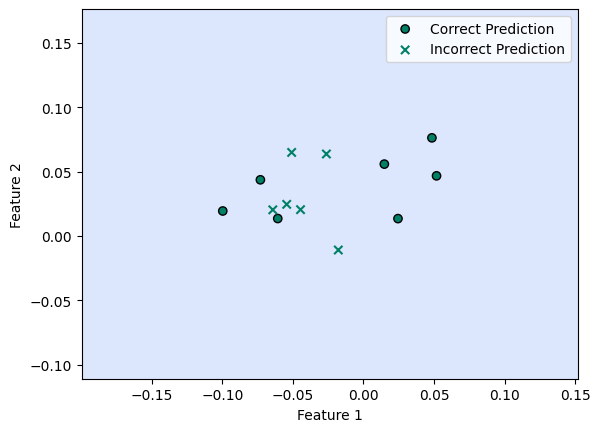

In [ ]:
class Perceptron:
    def __init__(self, input_size, lr=0.1, epochs=10):
        self.weights = np.zeros(input_size + 1)  # +1 for bias
        self.lr = lr
        self.epochs = epochs

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        x = np.insert(x, 0, 1)  # Add bias term
        return self.activation(np.dot(self.weights, x))

    def train(self, dataloader):
        with tqdm(range(self.epochs), total=self.epochs, desc="Epoch") as epoch_pbar:
            for epoch in epoch_pbar:
                with tqdm(dataloader, total=len(dataloader), desc=f"Batch {epoch+1}/{self.epochs}", leave=False) as batch_pbar:
                    for batch_X, batch_y in batch_pbar:
                        batch_X = batch_X.numpy()
                        batch_y = batch_y.numpy()


                        correct_predictions = 0  # Track the number of correct predictions
                        #perceptron learning method
                        for i in range(len(batch_X)):
                            prediction = self.predict(batch_X[i])
                            self.weights += self.lr * (batch_y[i] - prediction) * np.insert(batch_X[i], 0, 1)

                            if prediction == batch_y[i]:
                                correct_predictions += 1

                        # Calculate accuracy for the current batch
                        accuracy = correct_predictions / len(batch_X)
                        epoch_pbar.set_postfix({"accuracy": f"{accuracy:.2f}"})


    def plot_decision_boundary(self, X, y):
        X = np.vstack(X)
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

        Z = np.array([self.predict(np.array([xx_val, yy_val])) for xx_val, yy_val in zip(xx.ravel(), yy.ravel())])
        Z = Z.reshape(xx.shape)

        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        preds = np.array([self.predict(x) for x in X])

        correct = (preds == y)

        plt.scatter(X[correct, 0], X[correct, 1], c=y[correct], edgecolors='k', cmap="summer", marker='o', label="Correct Prediction")
        plt.scatter(X[~correct, 0], X[~correct, 1], c=y[~correct], edgecolors='k', cmap="summer", marker='x', label="Incorrect Prediction")

        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()



perceptron = Perceptron(input_size=2, lr=0.01, epochs=10)

#train perceptron model
perceptron.train(dummy_train_loader)

perceptron.plot_decision_boundary(dummy_X_train, dummy_y_train)

## Multi-Layer Perceptron - MLP (Simple Fully-Connected Neural Network)

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Batch 1/100:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 2/100:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 3/100:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 4/100:   0%|          | 0/4 [00:00<?, ?it/s]

...

Batch 96/100:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 97/100:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 98/100:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 99/100:   0%|          | 0/4 [00:00<?, ?it/s]

Batch 100/100:   0%|          | 0/4 [00:00<?, ?it/s]

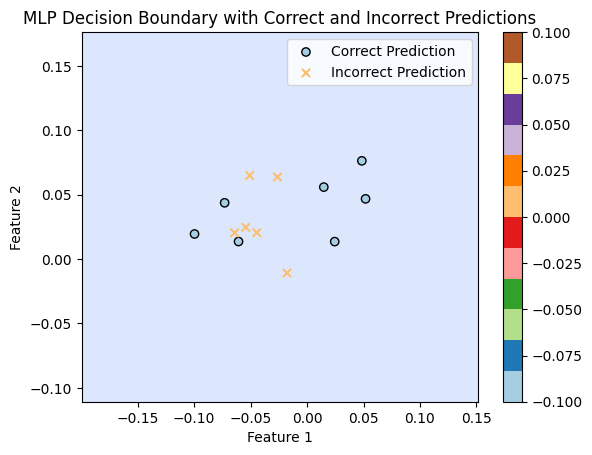

In [ ]:
# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

    def plot_decision_boundary(self, X, y):
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

        with torch.no_grad():
            preds = self(grid)  # Pass the grid through the model

        class_preds = torch.argmax(preds, dim=1).cpu().numpy().reshape(xx.shape)
        plt.contourf(xx, yy, class_preds, alpha=0.3, cmap=plt.cm.coolwarm)
        plt.contour(xx, yy, class_preds, levels=[0.5], linewidths=2, colors='black')  # Decision boundary line

        with torch.no_grad():
            true_preds = self(torch.tensor(X, dtype=torch.float32))  # True predictions
            true_class_preds = torch.argmax(true_preds, dim=1).cpu().numpy()

        correct = (true_class_preds == y)

        plt.scatter(X[correct, 0], X[correct, 1], c=y[correct], edgecolors='k', cmap=plt.cm.Paired, marker='o', label="Correct Prediction")
        plt.scatter(X[~correct, 0], X[~correct, 1], c=y[~correct], edgecolors='k', cmap=plt.cm.Paired, marker='x', label="Incorrect Prediction")

        # Set plot labels and title
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title("MLP Decision Boundary with Correct and Incorrect Predictions")
        plt.colorbar()
        plt.legend()
        plt.show()


# Set parameters
mlp = MLP(
    input_size=2,#10,  # This should match the FastText vector size (10 in this case)
    hidden_size=80,
    output_size=2  # Number of classes (adjust if necessary)
)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for multi-class classification
optimizer = optim.Adam(mlp.parameters(), lr=0.1)

# Training loop
epochs = 100
with tqdm(range(epochs), total=epochs, desc="Epoch") as epoch_pbar:
    for epoch in epoch_pbar:
        mlp.train()  # Set model to training mode
        running_loss = 0.0
        with tqdm(dummy_train_loader, total=len(dummy_train_loader), desc=f"Batch {epoch+1}/{epochs}", leave=False) as batch_pbar:
            for X_batch, y_batch in batch_pbar:
                optimizer.zero_grad()

                # Forward propagation
                outputs = mlp(X_batch)

                # Calculate loss
                loss = criterion(outputs, y_batch)

                # Backpropagation
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

                epoch_pbar.set_postfix({"loss": f"{loss.item():.2f}"})

mlp.plot_decision_boundary(dummy_X_train, dummy_y_train)

In [ ]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors and move to device
X_train_tensor = torch.tensor(X_train_avg, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_avg, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

# Create DataLoaders
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)


# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, hidden_size4, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.fc4 = nn.Linear(hidden_size3, hidden_size4)
        self.fc5 = nn.Linear(hidden_size4, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        x = self.sigmoid(x)
        x = self.fc5(x)
        x = self.softmax(x)
        return x

# Initialize model and move to GPU if available
mlp = MLP(
    input_size=300,
    hidden_size1=128,
    hidden_size2=64,
    hidden_size3=32,
    hidden_size4=8,
    output_size=2
).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.1)

# Training loop
epochs = 2
with tqdm(range(epochs), total=epochs, desc="Epoch") as epoch_pbar:
    for epoch in epoch_pbar:
        mlp.train()  # Set model to training mode
        running_loss = 0.0

        with tqdm(train_loader, total=len(train_loader), desc=f"Batch", leave=False) as batch_pbar:
            for X_batch, y_batch in batch_pbar:
                optimizer.zero_grad()

                # Forward pass
                outputs = mlp(X_batch)

                # Compute loss
                loss = criterion(outputs, y_batch)

                # Backpropagation
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                epoch_pbar.set_postfix({"loss": f"{loss.item():.2f}"})

# Model Evaluation
mlp.eval()
all_preds = []
all_labels = []

with torch.no_grad():  # Disable gradients for testing
    for X_batch, y_batch in test_loader:
        outputs = mlp(X_batch)
        _, predicted = torch.max(outputs, 1)  # Get class index
        all_preds.extend(predicted.cpu().numpy())  # Move to CPU before converting to numpy
        all_labels.extend(y_batch.cpu().numpy())

# Compute accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
test_accuracy = precision_score(all_labels, all_preds)
test_accuracy = recall_score(all_labels, all_preds)
test_accuracy = f1_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_accuracy:.4f}")
print(f"Test Recall: {test_accuracy:.4f}")
print(f"Test F1: {test_accuracy:.4f}")


Using device: cuda


NameError: name 'X_train_avg' is not defined

## Recurrent Neural Network - RNN

In [ ]:
# Data prep.
max_len = 30  # maximum sequence (sentence) length (number of word vectors)
def pad_or_truncate(sentences, max_len):
    padded_sentences = []
    for sentence in sentences:
        if len(sentence) < max_len:
            sentence = sentence + [np.zeros(sentence[0].shape)] * (max_len - len(sentence)) # Pad with zeros
        elif len(sentence) > max_len:
            sentence = sentence[:max_len] # Truncate sentences to max_len
        padded_sentences.append(sentence)
    return padded_sentences


# Apply padding/truncating to the training and test data
X_train_padded = pad_or_truncate(X_train, max_len)
X_test_padded = pad_or_truncate(X_test, max_len)

X_train_tensor = torch.tensor(X_train_padded, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_padded, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)  # Long for classification
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

# Create TensorDataset for training and test sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the RNN model
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)  # RNN layer
        self.fc = nn.Linear(hidden_size, output_size)  # Fully connected layer for classification

    def forward(self, x):
        # x is of shape (batch_size, seq_length, input_size)
        rnn_out, _ = self.rnn(x)  # Get RNN output, ignore hidden states
        last_hidden_state = rnn_out[:, -1, :]  # Get the last output (for classification)
        out = self.fc(last_hidden_state)  # Pass it through the fully connected layer
        return out

# Instantiate the model and move it to the GPU if available
model = RNNModel(
    input_size=300,  # Size of word vectors (e.g., FastText vector size)
    hidden_size=64,  # Number of hidden units in the RNN
    output_size=2,  # Number of classes (adjust if necessary)
    num_layers=1
).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 3
for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)  # Move input batch to device (GPU if available)
        y_batch = y_batch.to(device)  # Move labels to device

        optimizer.zero_grad()

        # Forward propagation
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()
        optimizer.step()

        running_loss += loss.item()


    model.eval()
    y_pred = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            _, predicted = torch.max(outputs, 1)  # Get the predicted classes
            y_pred.extend(predicted.cpu().numpy())  # Store predictions in CPU memory

        # Calculate metrics
        accuracy = accuracy_score(y_test_tensor.cpu().numpy(), y_pred)
        precision = precision_score(y_test_tensor.cpu().numpy(), y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test_tensor.cpu().numpy(), y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test_tensor.cpu().numpy(), y_pred, average='weighted', zero_division=0)

        print(f'- Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')



Using device: cuda
- Epoch [1/3], Loss: 0.7072, Accuracy: 0.5059, Precision: 0.5059, Recall: 0.5059, F1 Score: 0.5059
- Epoch [2/3], Loss: 0.7078, Accuracy: 0.4959, Precision: 0.4959, Recall: 0.4959, F1 Score: 0.4959
- Epoch [3/3], Loss: 0.7078, Accuracy: 0.5055, Precision: 0.5055, Recall: 0.5055, F1 Score: 0.5055


## Long Short Term Memory (LSTM) & Gated Recurrent Units (GRU)

In [ ]:
# Data prep.
max_len = 30  # maximum sequence (sentence) length (number of word vectors)
def pad_or_truncate(sentences, max_len):
    padded_sentences = []
    for sentence in sentences:
        if len(sentence) < max_len:
            sentence = sentence + [np.zeros(sentence[0].shape)] * (max_len - len(sentence)) # Pad with zeros
        elif len(sentence) > max_len:
            sentence = sentence[:max_len] # Truncate sentences to max_len
        padded_sentences.append(sentence)
    return padded_sentences


# Apply padding/truncating to the training and test data
X_train_padded = pad_or_truncate(X_train, max_len)
X_test_padded = pad_or_truncate(X_test, max_len)

X_train_tensor = torch.tensor(X_train_padded, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_padded, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)  # Long for classification
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

# Create TensorDataset for training and test sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2, bidirectional=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)  # Take the last hidden state
        out = self.fc(hn[-1])  # Fully connected layer
        return out

# Define GRU model
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2, bidirectional=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, hn = self.gru(x)  # Take the last hidden state
        out = self.fc(hn[-1])  # Fully connected layer
        return out

# Model parameters
input_dim = 300  # Assuming word vectors as features (e.g., FastText vector size)
hidden_dim = 64
output_dim = 2  # Number of classes
num_layers = 1

# Initialize models and move them to device
lstm_model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
gru_model = GRUModel(input_dim, hidden_dim, output_dim, num_layers).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
gru_optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

# Training function
def train_model(model, optimizer, train_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)  # Move input batch to device
            batch_y = batch_y.to(device)  # Move labels to device

            optimizer.zero_grad()
            outputs = model(batch_X)  # Forward pass
            loss = criterion(outputs, batch_y)  # Calculate loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Optimize

            running_loss += loss.item()

        # Evaluation (on the training set)
        with torch.no_grad():
            model.eval()  # Set model to evaluation mode
            y_pred = []

            # Collect predictions for the entire dataset
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)  # Get the predicted classes
                y_pred.extend(predicted.cpu().numpy())  # Store predictions in CPU memory

            # Calculate metrics
            accuracy = accuracy_score(y_test_tensor.cpu().numpy(), y_pred)
            precision = precision_score(y_test_tensor.cpu().numpy(), y_pred, average='weighted', zero_division=0)
            recall = recall_score(y_test_tensor.cpu().numpy(), y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test_tensor.cpu().numpy(), y_pred, average='weighted', zero_division=0)

        print(f'- Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

# Train LSTM and GRU models
print("Training LSTM Model...")
train_model(lstm_model, lstm_optimizer, train_loader)

print("Training GRU Model...")
train_model(gru_model, gru_optimizer, train_loader)


Using device: cuda
Training LSTM Model...
- Epoch [1/10], Loss: 0.5672, Accuracy: 0.7093, Precision: 0.7265, Recall: 0.7093, F1 Score: 0.7037
- Epoch [2/10], Loss: 0.5255, Accuracy: 0.7263, Precision: 0.7380, Recall: 0.7263, F1 Score: 0.7229
- Epoch [3/10], Loss: 0.5069, Accuracy: 0.7392, Precision: 0.7419, Recall: 0.7392, F1 Score: 0.7385
- Epoch [4/10], Loss: 0.4912, Accuracy: 0.7419, Precision: 0.7442, Recall: 0.7419, F1 Score: 0.7414
- Epoch [5/10], Loss: 0.4797, Accuracy: 0.7506, Precision: 0.7506, Recall: 0.7506, F1 Score: 0.7505
- Epoch [6/10], Loss: 0.4692, Accuracy: 0.7467, Precision: 0.7497, Recall: 0.7467, F1 Score: 0.7459
- Epoch [7/10], Loss: 0.4587, Accuracy: 0.7503, Precision: 0.7508, Recall: 0.7503, F1 Score: 0.7502
- Epoch [8/10], Loss: 0.4485, Accuracy: 0.7578, Precision: 0.7578, Recall: 0.7578, F1 Score: 0.7578
- Epoch [9/10], Loss: 0.4400, Accuracy: 0.7525, Precision: 0.7539, Recall: 0.7525, F1 Score: 0.7522
- Epoch [10/10], Loss: 0.4314, Accuracy: 0.7488, Precision

# Transformer models (LLMs)

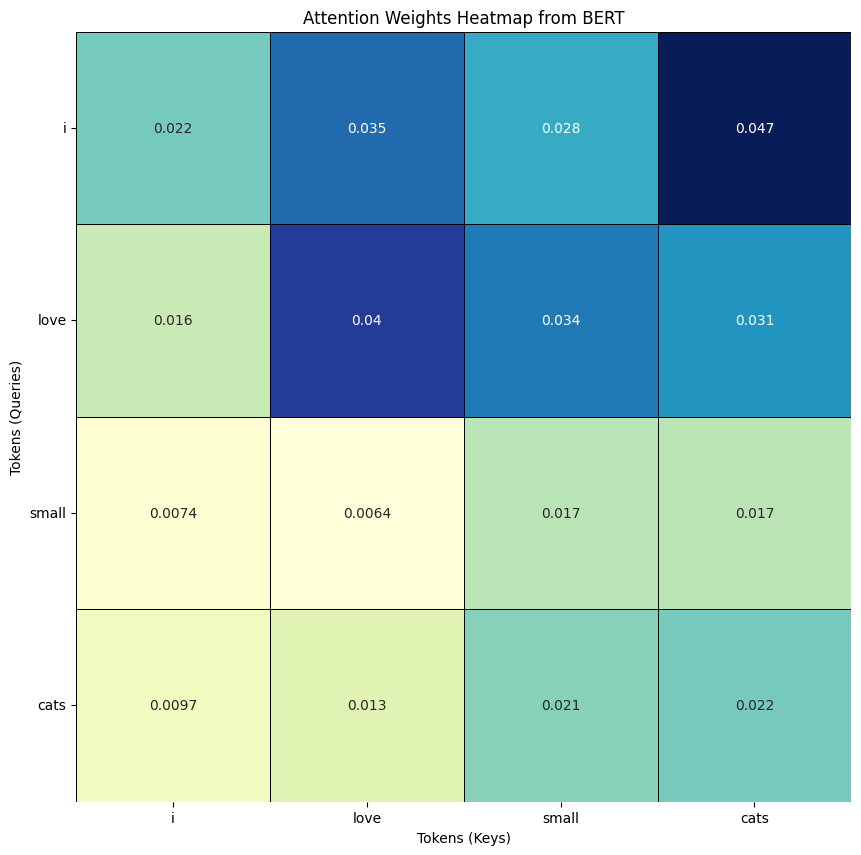

In [ ]:
model_name = "bert-base-uncased"

text = "Computing attention for all tokens in the sentence"
text = "I love small cats"

plot_attention(text, model_name)

## Data prep. for LLMs

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
E9_LABELS_DICT = {
    0: 'Anger',
    1: 'Fear',
    2: 'Disgust',
    3: 'Sadness',
    4: 'Joy',
    5: 'None of Them',
    6: 'Enthusiasm',
    7: 'Hope',
    8: 'Pride'
}

E9_2_SENTIMENT_DICT = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 1,
    5: 2,
    6: 1,
    7: 1,
    8: 1
}

SENTIMENT_DICT = {
    0: 'Negative',
    1: 'Positive',
    2: 'Neutral'
}

#read csv
df = pd.read_csv('/content/drive/MyDrive/hu_telex_2020_2024_for_e9_all_sentences_preds.csv')

#rename columns
df = df.rename(columns={'pred':'label', 'pred_name': 'label_name'})

df.label = df.label.astype(int)

df['label_name'] = df['label'].map(E9_LABELS_DICT)

#keep only relevant columns
df = df[['id', 'text', 'label', 'label_name']]

#map E9 labels to Sentiment labels
df['label'] = df['label'].map(E9_2_SENTIMENT_DICT)

#drop None of them category
df = df[df['label_name'] != 'None of Them']

#map sentiment labels
df['label_name'] = df['label'].map(SENTIMENT_DICT)

#remove rows with less than 50 characters
min_char_length = 100
max_char_length = 150
df = df[(df['text'].str.len() > min_char_length) & (df['text'].str.len() < max_char_length)]

#sample 1000 positive and 1000 negative examples
df = pd.concat(
    [
        df[df['label_name'] == 'Positive'].sample(n=1000, random_state=42),
        df[df['label_name'] == 'Negative'].sample(n=1000, random_state=42)
    ]
)

#shuffle the dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.label_name.value_counts()

,count
label_name,
Negative,1000
Positive,1000


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
def tokenize_function(tokenizer, examples, col_name="text", max_length=30):
    return tokenizer(examples[col_name], truncation=True, padding="max_length", max_length=max_length)

## Translation with LLMs

In [ ]:
import pandas as pd
from transformers import MarianMTModel, MarianTokenizer
from tqdm import tqdm
import torch

model_name = 'Helsinki-NLP/opus-mt-hu-en'

model = MarianMTModel.from_pretrained(model_name).to(device)  # Move model to GPU (if available)
tokenizer = MarianTokenizer.from_pretrained(model_name)

#translation with batch processing
def translate_batch(batch_texts, model, tokenizer, batch_size=8):
    inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {key: value.to(device) for key, value in inputs.items()}  # Move inputs to GPU

    with torch.no_grad():
        translated = model.generate(**inputs)

    translated_texts = tokenizer.batch_decode(translated, skip_special_tokens=True)
    return translated_texts

def process_in_batches(df, batch_size=8):
    translated_texts = []

    for start_idx in tqdm(range(0, len(df), batch_size), desc="Translating in batches"):
        batch_texts = df['text'].iloc[start_idx:start_idx + batch_size].tolist()
        batch_translated = translate_batch(batch_texts, model, tokenizer, batch_size)
        translated_texts.extend(batch_translated)

    return translated_texts

train_df['english_text'] = process_in_batches(train_df, batch_size=80)  # Set your desired batch size
test_df['english_text'] = process_in_batches(test_df, batch_size=80)  # Set your desired batch size

Translating in batches: 100%|██████████| 5/5 [00:24<00:00,  4.83s/it]


## BERT

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

#create datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

#tokenize data
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

tokenized_train_dataset = train_dataset.map(lambda x: tokenize_function(tokenizer, x, col_name="english_text", max_length=30), batched=True)
tokenized_test_dataset = test_dataset.map(lambda x: tokenize_function(tokenizer, x, col_name="english_text", max_length=30), batched=True)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(p):
    predictions, labels = p
    preds = np.argmax(predictions, axis=1)
    return {'accuracy': accuracy_score(labels, preds)}

In [ ]:
import os
os.environ['WANDB_DISABLED']= "true"
#torch format
tokenized_train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Load the pre-trained BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2).to(device)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
)

# Fine-tune the model
trainer.train()

# Evaluate the model
results = trainer.evaluate()
print(f"Accuracy: {results['eval_accuracy']}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy
1,0.373800,0.364755,0.852500
2,0.318500,0.294975,0.887500
3,0.203300,0.310185,0.882500


Accuracy: 0.8825


In [ ]:
predictions_output = trainer.predict(tokenized_test_dataset)

# Extract logits and convert to class predictions
logits = predictions_output.predictions  # Raw model outputs
predicted_labels = torch.argmax(torch.tensor(logits), dim=1).numpy()  # Convert logits to class labels

test_df['BERT-pred'] = predicted_labels

test_df

,id,text,label,label_name,english_text,BERT-pred
1860,da5e9b36cd68ee436445e4eec5e8141f_11,"Anyjával, Ancsával évek óta egy ötven négyzetm...",0,Negative,"His mother, Ancsa, has been living in a 50 squ...",0
353,7312071124e7cd67ceed83b97f0f13b1_12,"A buszt egy olasz sofőr, a 40 éves Alberto Riz...",0,Negative,"The bus was driven by an Italian driver, a 40-...",0
1333,9292e3040b8f0bf7e73325b39f14cb2a_8,A a felmondásunk után olvasói támogatásokból j...,1,Positive,"Following our resignation, it was possible to ...",1
905,bb420554816cac10f944466206eac330_5,Ha a lányok nem kapták volna meg ezt a lehetős...,0,Negative,If the girls hadn't gotten this opportunity fr...,0
1289,9474c59d4a303134d1a8621d7eec6b48_14,A válogatottban az októberi két meccsen négysz...,1,Positive,"In the two games in October, she was successfu...",1
...,...,...,...,...,...,...
965,2ec52a682e0fdd33504e28fcb30e0571_56,A palesztin polgári védelem adatai szerint leg...,0,Negative,According to Palestinian civil protection data...,0
1284,6d2359dd2d56f6c34b8ab47286779aeb_15,Orbán szerint tehát ketten maradtak a béke pár...,1,Positive,"So, according to Orbán, two of them remained a...",1
1739,d6c79d622192ca6b097468506e75bb5d_2,"Ha Szoledart elfoglalják, akkor újabb irányból...",0,Negative,"If Soledar is captured, they can attack Bahmut...",0
261,8ae1bd4d5d97721d66039902a6793af5_61,"Kérdés viszont, hogy megtartották-e a reagálás...",0,Negative,"The question, however, is whether they have ma...",0


## XLM-RoBERTa

In [ ]:
#create datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

#tokenize data
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

tokenized_train_dataset = train_dataset.map(lambda x: tokenize_function(tokenizer, x, col_name="text", max_length=30), batched=True)
tokenized_test_dataset = test_dataset.map(lambda x: tokenize_function(tokenizer, x, col_name="text", max_length=30), batched=True)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [ ]:
#torch format
tokenized_train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Load the pre-trained BERT model
model = AutoModelForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2).to(device)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
)

# Fine-tune the model
trainer.train()

# Evaluate the model
results = trainer.evaluate()
print(f"Accuracy: {results['eval_accuracy']}")


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy
1,0.607400,0.536961,0.717500
2,0.443400,0.364681,0.860000
3,0.335700,0.350601,0.867500
4,0.314300,0.398529,0.860000
5,0.329600,0.394597,0.862500


Accuracy: 0.8625


## GPT-2

In [ ]:
#create prompts from labels and texts
train_df["prompt"] = "Label: " + train_df["label_name"].astype(str) + " → " + train_df["english_text"].astype(str)
test_df["prompt"] = "Label: " + test_df["label_name"].astype(str) + " → " + test_df["english_text"].astype(str)

In [ ]:
#create datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

model_name = "gpt2-medium"

#tokenize data
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # Avoid padding issues

tokenized_train_dataset = train_dataset.map(lambda x: tokenize_function(tokenizer, x, col_name="prompt", max_length=30), batched=True)
tokenized_test_dataset = test_dataset.map(lambda x: tokenize_function(tokenizer, x, col_name="prompt", max_length=30), batched=True)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [ ]:
import os
os.environ['WANDB_DISABLED']="true"

# load pre-trained model
model = GPT2LMHeadModel.from_pretrained(model_name)
model.to(device)

# training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=2,
    logging_steps=10,
)

# Data collator for padding
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator
)

trainer.train()


model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.375900,3.368249
2,3.065000,3.353081
3,2.949500,3.355290


TrainOutput(global_step=300, training_loss=3.203585745493571, metrics={'train_runtime': 192.21, 'train_samples_per_second': 24.973, 'train_steps_per_second': 1.561, 'total_flos': 261197070336000.0, 'train_loss': 3.203585745493571, 'epoch': 3.0})

### determinisztikusan generált szöveg (paraméterek nélkül)

In [ ]:
input_text = "Label: " + "Positive" + " → "

tokenized_inputs = tokenizer.encode(input_text, return_tensors="pt").to(device)

outputs = model.generate(tokenized_inputs, max_length=50)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print('\n')
print(generated_text)



Label: Positive → 0 • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • •


### nem-determinisztikusan generált szöveg (paraméterezés)

In [ ]:
input_text = "Label: " + "Positive" + " → "

tokenized_inputs = tokenizer.encode(input_text, return_tensors='pt').to(device)

output = model.generate(
    tokenized_inputs,
    max_length=50,
    temperature=0.7,  # temperature for more randomness (higher = more random)
    top_k=150,  # Consider top 150 tokens
    top_p=0.7,  # Further filter to make sure the cumulative probability is >= 0.7
    do_sample=True    # Ensure the model samples (not greedy search)
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print('\n')
print(generated_text)



Label: Positive →  • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • • •
